# Boston Housing Regression Baseline

This notebook starts with a linear regression model as the baseline and then compares it with a Random Forest Regressor.

The target is the median home value column, `MEDV`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the Boston Housing dataset
url = 'https://raw.githubusercontent.com/dphi-official/Datasets/master/Boston_Housing/Training_set_boston.csv'
df = pd.read_csv(url)

print(df.head())
print('\nShape:', df.shape)
print('\nColumns:', list(df.columns))

       CRIM    ZN  INDUS  CHAS     NOX     RM   AGE     DIS   RAD    TAX  \
0  15.02340   0.0  18.10   0.0  0.6140  5.304  97.3  2.1007  24.0  666.0   
1   0.62739   0.0   8.14   0.0  0.5380  5.834  56.5  4.4986   4.0  307.0   
2   0.03466  35.0   6.06   0.0  0.4379  6.031  23.3  6.6407   1.0  304.0   
3   7.05042   0.0  18.10   0.0  0.6140  6.103  85.1  2.0218  24.0  666.0   
4   0.72580   0.0   8.14   0.0  0.5380  5.727  69.5  3.7965   4.0  307.0   

   PTRATIO       B  LSTAT  MEDV  
0     20.2  349.48  24.91  12.0  
1     21.0  395.62   8.47  19.9  
2     16.9  362.25   7.83  19.4  
3     20.2    2.52  23.29  13.4  
4     21.0  390.95  11.28  18.2  

Shape: (404, 14)

Columns: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']


In [3]:
# Define feature matrix and target
X = df.drop(columns=['MEDV'])
y = df['MEDV']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression baseline
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print('Linear Regression MAE:', lr_mae)
print('Linear Regression RMSE:', lr_rmse)
print('Linear Regression R^2:', lr_r2)

Linear Regression MAE: 3.2107604829377454
Linear Regression RMSE: 4.825602351498201
Linear Regression R^2: 0.6724827989037963


In [6]:
# Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    max_depth=None
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print('Random Forest MAE:', rf_mae)
print('Random Forest RMSE:', rf_rmse)
print('Random Forest R^2:', rf_r2)

Random Forest MAE: 2.4932666666666674
Random Forest RMSE: 3.901498372056629
Random Forest R^2: 0.7859112181643019


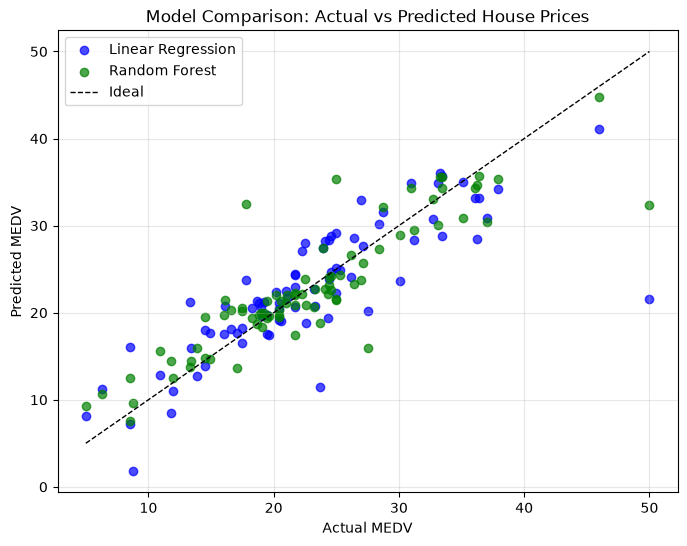

In [7]:
# Compare actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, lr_pred, alpha=0.7, color='blue', label='Linear Regression')
plt.scatter(y_test, rf_pred, alpha=0.7, color='green', label='Random Forest')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='black', linestyle='--', lw=1, label='Ideal')
plt.xlabel('Actual MEDV')
plt.ylabel('Predicted MEDV')
plt.title('Model Comparison: Actual vs Predicted House Prices')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Top 5 features by absolute coefficient (Linear Regression):
NOX        18.947892
RM          4.957726
CHAS        3.007626
DIS         1.512427
PTRATIO     0.935132
dtype: float64

Top 5 features by importance (Random Forest):
RM       0.609347
LSTAT    0.225227
DIS      0.047338
CRIM     0.034852
TAX      0.018026
dtype: float64


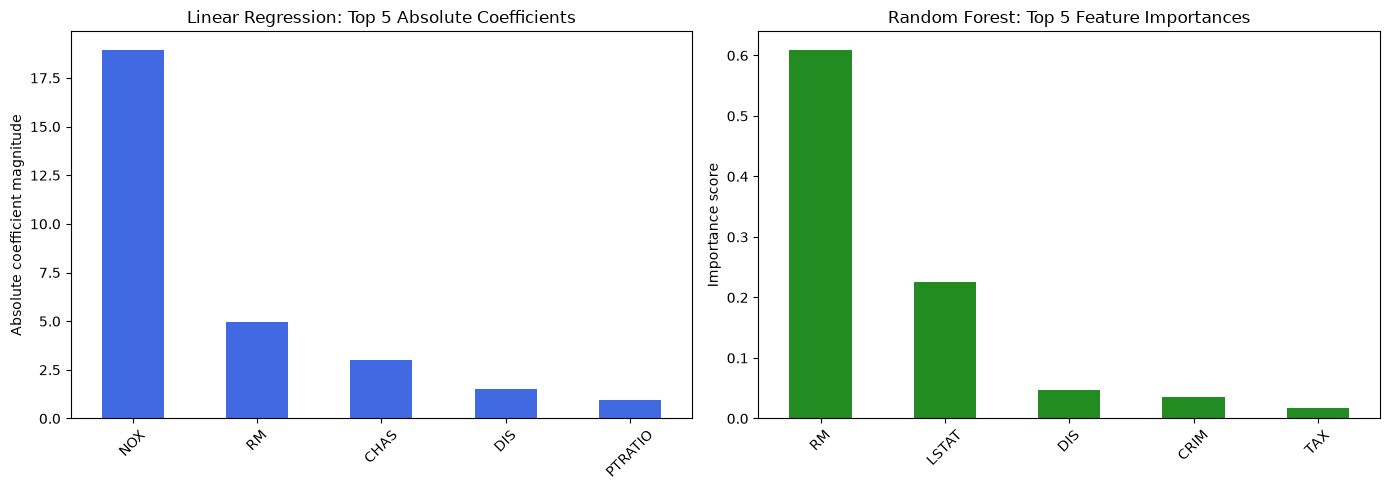

In [8]:
# Top 5 feature importance comparison

# Linear regression coefficients: magnitude shows importance but sign matters
lr_coefs = pd.Series(lr_model.coef_, index=X.columns)
lr_top5 = lr_coefs.abs().sort_values(ascending=False).head(5)
print('Top 5 features by absolute coefficient (Linear Regression):')
print(lr_top5)

# Random Forest feature importance
rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
rf_top5 = rf_importance.sort_values(ascending=False).head(5)
print('\nTop 5 features by importance (Random Forest):')
print(rf_top5)

# Plot side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lr_top5.plot(kind='bar', ax=axes[0], color='royalblue')
axes[0].set_title('Linear Regression: Top 5 Absolute Coefficients')
axes[0].set_ylabel('Absolute coefficient magnitude')
axes[0].tick_params(axis='x', rotation=45)

rf_top5.plot(kind='bar', ax=axes[1], color='forestgreen')
axes[1].set_title('Random Forest: Top 5 Feature Importances')
axes[1].set_ylabel('Importance score')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler

# Fix randomness for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Standardize features for neural network training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.to_numpy(), dtype=torch.float32).view(-1, 1)
y_test_t = torch.tensor(y_test.to_numpy(), dtype=torch.float32).view(-1, 1)

# Define the model
class DNNRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 10),
            nn.ReLU(),
            nn.Linear(10, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
        )

    def forward(self, x):
        return self.net(x)

model = DNNRegressor(X_train_t.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

loss_history = []

for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

model.eval()
with torch.no_grad():
    dnn_pred = model(X_test_t).numpy().flatten()

dnn_mae = mean_absolute_error(y_test, dnn_pred)
dnn_rmse = np.sqrt(mean_squared_error(y_test, dnn_pred))
dnn_r2 = r2_score(y_test, dnn_pred)

print('DNN MAE:', dnn_mae)
print('DNN RMSE:', dnn_rmse)
print('DNN R^2:', dnn_r2)

# Plot learning curve
plt.figure(figsize=(8, 5))
plt.plot(loss_history, label='Train Loss')
plt.title('PyTorch DNN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

ModuleNotFoundError: No module named 'tensorflow'